Converted DFA States        : ['{q0,q1}', '{q0,q2}', '{q0}']
Converted DFA Start State   : {q0}
Converted DFA Accept States  : {'{q0,q2}'}
Converted DFA Transitions   : {'{q0}': {'0': '{q0,q1}', '1': '{q0}'}, '{q0,q1}': {'0': '{q0,q1}', '1': '{q0,q2}'}, '{q0,q2}': {'0': '{q0,q1}', '1': '{q0}'}}


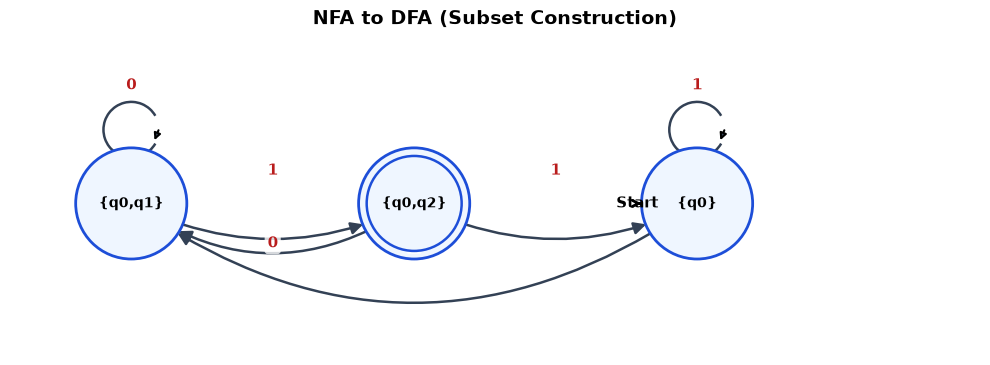


--- Converted DFA Simulation ---
Input string : 1001
Path taken   : {q0} -> {q0} -> {q0,q1} -> {q0,q1} -> {q0,q2}
Status       : ACCEPTED ✅


In [1]:
from collections import deque
import matplotlib.patches as patches
import matplotlib.pyplot as plt
import numpy as np


class NFA:

  def __init__(
      self, states, alphabet, transition_function, start_state, accept_states
  ):
    self.states = set(states)
    self.alphabet = set(alphabet)
    self.transition_function = transition_function
    self.start_state = start_state
    self.accept_states = set(accept_states)

  def to_dfa(self):
    """Converts the NFA to an equivalent DFA using Subset Construction."""
    # Start state of DFA is the set containing only the NFA start state
    initial_dfa_state = frozenset([self.start_state])

    unprocessed_states = deque([initial_dfa_state])
    dfa_states = {initial_dfa_state}
    dfa_transitions = {}
    dfa_accept_states = set()

    while unprocessed_states:
      current_subset = unprocessed_states.popleft()
      dfa_transitions[current_subset] = {}

      # If any state in the subset is an accept state in NFA, mark as accept in DFA
      if any(state in self.accept_states for state in current_subset):
        dfa_accept_states.add(current_subset)

      for symbol in self.alphabet:
        # Compute the union of all transitions for the current symbol
        next_subset = set()
        for state in current_subset:
          if (
              state in self.transition_function
              and symbol in self.transition_function[state]
          ):
            next_subset.update(self.transition_function[state][symbol])

        next_subset_frozen = frozenset(next_subset)

        # Handle valid non-empty transitions
        if next_subset_frozen:
          dfa_transitions[current_subset][symbol] = next_subset_frozen

          if next_subset_frozen not in dfa_states:
            dfa_states.add(next_subset_frozen)
            unprocessed_states.append(next_subset_frozen)

    # Convert frozensets to clean readable string names (e.g., {q0, q1} -> "{q0,q1}")
    name_map = {
        subset: (
            "{" + ",".join(sorted(subset)) + "}" if subset else "∅"
        )
        for subset in dfa_states
    }

    formatted_states = {name_map[s] for s in dfa_states}
    formatted_start_state = name_map[initial_dfa_state]
    formatted_accept_states = {name_map[s] for s in dfa_accept_states}
    formatted_transitions = {}

    for src_subset, sym_dict in dfa_transitions.items():
      src_name = name_map[src_subset]
      formatted_transitions[src_name] = {}
      for sym, dst_subset in sym_dict.items():
        formatted_transitions[src_name][sym] = name_map[dst_subset]

    return DFA(
        formatted_states,
        self.alphabet,
        formatted_transitions,
        formatted_start_state,
        formatted_accept_states,
    )


class DFA:

  def __init__(
      self, states, alphabet, transition_function, start_state, accept_states
  ):
    self.states = sorted(list(states))
    self.alphabet = set(alphabet)
    self.transition_function = transition_function
    self.start_state = start_state
    self.accept_states = set(accept_states)

  def trace(self, input_string):
    current_state = self.start_state
    path = [current_state]
    for symbol in input_string:
      if symbol not in self.alphabet:
        return False, path
      if symbol not in self.transition_function.get(current_state, {}):
        return False, path
      current_state = self.transition_function[current_state][symbol]
      path.append(current_state)
    return current_state in self.accept_states, path

  def visualize_matplotlib(self, test_string=None):
    fig, ax = plt.subplots(figsize=(10, 5))

    # Calculate horizontal layout dynamically for generated states
    num_nodes = len(self.states)
    pos = {}
    for i, state in enumerate(self.states):
      pos[state] = np.array([1.2 + i * 2.8, 2.0])

    r = 0.55  # Radius sized to fit subset names like {q0,q1}

    # 1. Draw States
    for state, (x, y) in pos.items():
      circle = plt.Circle(
          (x, y),
          r,
          facecolor="#eff6ff",
          edgecolor="#1d4ed8",
          linewidth=2,
          zorder=3,
      )
      ax.add_patch(circle)

      if state in self.accept_states:
        inner_circle = plt.Circle(
            (x, y),
            r - 0.08,
            facecolor="#eff6ff",
            edgecolor="#1d4ed8",
            linewidth=1.8,
            zorder=4,
        )
        ax.add_patch(inner_circle)

      ax.text(
          x,
          y,
          state,
          ha="center",
          va="center",
          fontsize=10,
          fontweight="bold",
          zorder=5,
      )

    # 2. Start State Arrow
    sx, sy = pos[self.start_state]
    ax.annotate(
        "Start",
        xy=(sx - r, sy),
        xytext=(sx - 0.8, sy),
        arrowprops=dict(facecolor="black", arrowstyle="->", lw=2),
        fontsize=11,
        fontweight="bold",
        va="center",
    )

    # 3. Transitions & Self-loops
    for src, transitions in self.transition_function.items():
      # Group identical destination transitions
      merged_dsts = {}
      for sym, dst in transitions.items():
        merged_dsts.setdefault(dst, []).append(sym)

      for dst, symbols in merged_dsts.items():
        label = ",".join(sorted(symbols))
        p1 = pos[src]
        p2 = pos[dst]

        if src == dst:
          # Draw self-loop
          x, y = p1
          loop = patches.Arc(
              (x, y + r + 0.18),
              0.55,
              0.55,
              angle=0,
              theta1=30,
              theta2=330,
              color="#334155",
              lw=1.8,
          )
          ax.add_patch(loop)
          ax.annotate(
              "",
              xy=(x + 0.22, y + r + 0.05),
              xytext=(x + 0.28, y + r + 0.2),
              arrowprops=dict(facecolor="#334155", arrowstyle="-|>", lw=1.5),
          )
          ax.text(
              x,
              y + r + 0.58,
              label,
              fontsize=11,
              fontweight="bold",
              color="#b91c1c",
              ha="center",
          )
        else:
          # Compute curvature direction based on node order
          src_idx = self.states.index(src)
          dst_idx = self.states.index(dst)
          rad = 0.25 if dst_idx > src_idx else -0.35

          arrow = patches.FancyArrowPatch(
              posA=(p1[0], p1[1]),
              posB=(p2[0], p2[1]),
              connectionstyle=f"arc3,rad={rad}",
              arrowstyle="-|>",
              mutation_scale=18,
              color="#334155",
              lw=1.8,
              shrinkA=r * 72,
              shrinkB=r * 72,
              zorder=2,
          )
          ax.add_patch(arrow)

          mid_x = (p1[0] + p2[0]) / 2
          mid_y = (p1[1] + p2[1]) / 2 + (rad * 0.7) + (0.15 if rad > 0 else -0.15)
          ax.text(
              mid_x,
              mid_y,
              label,
              fontsize=11,
              fontweight="bold",
              color="#b91c1c",
              ha="center",
              va="center",
              bbox=dict(
                  boxstyle="round,pad=0.2",
                  facecolor="white",
                  edgecolor="none",
                  alpha=0.8,
              ),
          )

    ax.set_xlim(0, len(self.states) * 2.8 + 1.2)
    ax.set_ylim(0.5, 3.5)
    ax.set_aspect("equal")
    plt.title(
        "NFA to DFA (Subset Construction)",
        fontsize=14,
        fontweight="bold",
        pad=20,
    )
    plt.axis("off")
    plt.tight_layout()
    plt.show()

    if test_string is not None:
      accepted, path = self.trace(test_string)
      verdict = "ACCEPTED ✅" if accepted else "REJECTED ❌"
      print(f"\n--- Converted DFA Simulation ---")
      print(f"Input string : {test_string}")
      print(f"Path taken   : {' -> '.join(path)}")
      print(f"Status       : {verdict}")


# ==========================================================
# Example: Convert NFA for strings ending in '01' to DFA
# ==========================================================

nfa_states = {"q0", "q1", "q2"}
nfa_alphabet = {"0", "1"}
nfa_start = "q0"
nfa_accept = {"q2"}

nfa_transitions = {
    "q0": {"0": {"q0", "q1"}, "1": {"q0"}},
    "q1": {"1": {"q2"}},
    "q2": {},
}

# 1. Initialize NFA
nfa = NFA(nfa_states, nfa_alphabet, nfa_transitions, nfa_start, nfa_accept)

# 2. Convert to DFA
dfa = nfa.to_dfa()

# 3. Print the generated DFA details
print("Converted DFA States        :", dfa.states)
print("Converted DFA Start State   :", dfa.start_state)
print("Converted DFA Accept States  :", dfa.accept_states)
print("Converted DFA Transitions   :", dfa.transition_function)

# 4. Visualize and trace a test string
dfa.visualize_matplotlib(test_string="1001")